<a href="https://colab.research.google.com/github/dharanidhar-pro/ML-SKILL/blob/main/skill_week4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
'/content/drive/MyDrive/Colab/age_insurance.csv'

'/content/drive/MyDrive/Colab/age_insurance.csv'

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [4]:
df = pd.read_csv("/content/drive/MyDrive/colab/age_insurance.csv")

print(df.head())
print(df.shape)

   Age  Insurance  InsurancePlan
0   56          0              0
1   69          1              2
2   46          1              2
3   32          0              0
4   60          1              2
(300, 3)


In [5]:
print("\nPART 1: BINARY LOGISTIC REGRESSION")
print("-" * 45)

X = df[["Age"]]          # Feature
y = df["Insurance"]      # Target

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=12
)

binary_model = LogisticRegression()

binary_model.fit(X_train, y_train)

y_pred = binary_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

print(classification_report(
    y_test,
    y_pred,
    target_names=["No Insurance", "Has Insurance"]
))

print("Confusion matrix:\n", confusion_matrix(y_test, y_pred))


PART 1: BINARY LOGISTIC REGRESSION
---------------------------------------------
Accuracy: 0.7
               precision    recall  f1-score   support

 No Insurance       0.63      0.73      0.68        26
Has Insurance       0.77      0.68      0.72        34

     accuracy                           0.70        60
    macro avg       0.70      0.70      0.70        60
 weighted avg       0.71      0.70      0.70        60

Confusion matrix:
 [[19  7]
 [11 23]]


In [6]:
new_age = pd.DataFrame({"Age": [22, 45, 63]})

predictions = binary_model.predict(new_age)

print(predictions)

probabilities = binary_model.predict_proba(new_age)[:, 1]

for age_val, pred, prob in zip(
    new_age["Age"],
    predictions,
    probabilities
):
    print(
        f"Age {age_val}: Insurance = {pred} "
        f"(Probability of Yes = {prob:.2f})"
    )

[0 1 1]
Age 22: Insurance = 0 (Probability of Yes = 0.06)
Age 45: Insurance = 1 (Probability of Yes = 0.67)
Age 63: Insurance = 1 (Probability of Yes = 0.97)


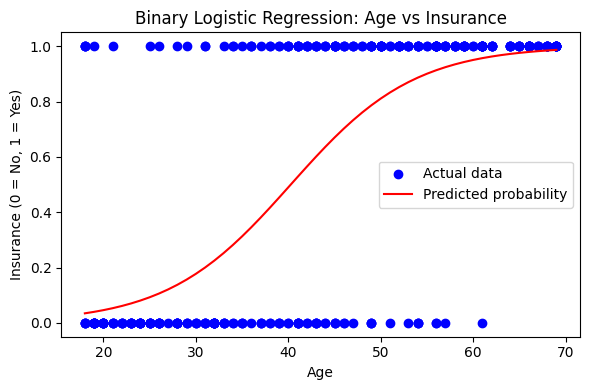


Saved plot -> binary_logistic_plot.png


In [7]:
plt.figure(figsize=(6, 4))

plt.scatter(
    df["Age"],
    df["Insurance"],
    color="blue",
    label="Actual data"
)

age_range = pd.DataFrame({
    "Age": range(18, 70)
})

plt.plot(
    age_range["Age"],
    binary_model.predict_proba(age_range)[:, 1],
    color="red",
    label="Predicted probability"
)

plt.xlabel("Age")
plt.ylabel("Insurance (0 = No, 1 = Yes)")
plt.title("Binary Logistic Regression: Age vs Insurance")
plt.legend()
plt.tight_layout()

plt.savefig("binary_logistic_plot.png")

plt.show()

print("\nSaved plot -> binary_logistic_plot.png")